In [1]:
using BSON: @load
using DriftDiffusionModels
using HiddenMarkovModels
using DataFrames
using CSV
using Dates
using Printf
using Statistics
using StatsPlots
using StatsBase
using Base.Threads: @threads
using Random

## Preprocessing

In [63]:
rat = "Remy"

# set ddir
path_to_rat = joinpath(@__DIR__, "..", "data", rat * "_K4_best.bson")

# load in rat data, need trhe following struct
struct DDMHMMFit
    hmm::PriorHMM
    logL::Float64
    logL_evolution::Vector{Float64}
end

# load in rat data
@load path_to_rat fit

# our fit HMM model
hmm = fit.hmm 

# set data path (assumes you are in the project root)
data_file = joinpath(@__DIR__, "..", "data", "processed_rat_data.csv.gz")

# Read in and structure data
rat_df = CSV.read(data_file, DataFrame)
rat_df = rat_df[rat_df.daily .== "24 hr", :] # only keep 24 hour data

# preprocess the data to have numerics
replace!(rat_df[!, :choose_right], 0 => -1)

mapping = Dict("right" => 1, "left" => -1)
DataFrames.transform!(rat_df, :correct_side => ByRow(cs -> get(mapping, cs, missing)) => :correct_side_numeric)

rat_of_interest = rat_df[rat_df.name .== rat, :] # use Robert for analysis
dates = [Date(split(dt)[1]) for dt in rat_of_interest.trial_datetime]
	
# Get unique dates in chronological order
unique_dates = sort(unique(dates))
	
# Create a vector of vectors, where each inner vector contains DDMResults for one day
results_by_date = Vector{Vector{DDMResult}}()
	
for date in unique_dates
	# Get indices for this date
	day_indices = findall(dates .== date)

	# Skip days with no valid data
	if isempty(day_indices)
		continue
	end

	# Extract RTs and outcomes for this date
	day_rts = rat_of_interest.rt[day_indices]
	day_outcomes = rat_of_interest.choose_right[day_indices]
	day_stim_side = rat_of_interest.correct_side_numeric[day_indices]
	    
	# Create DDMResult objects for this day
	day_results = [DDMResult(rt, choice, stim) for (rt, choice, stim) in zip(day_rts, day_outcomes, day_stim_side)]
	
	# Add to our vector of vectors
	push!(results_by_date, day_results)
end 

all_results = vcat(results_by_date...)  # flatten to all results
seq_ends = cumsum(length.(results_by_date))  # sequence ends for HMM

10-element Vector{Int64}:
  1109
  4053
  6206
  8190
 11075
 14234
 16730
 19401
 22507
 23482

## State Occupancy Plot

max deviation from 1: 3.3306690738754696e-15


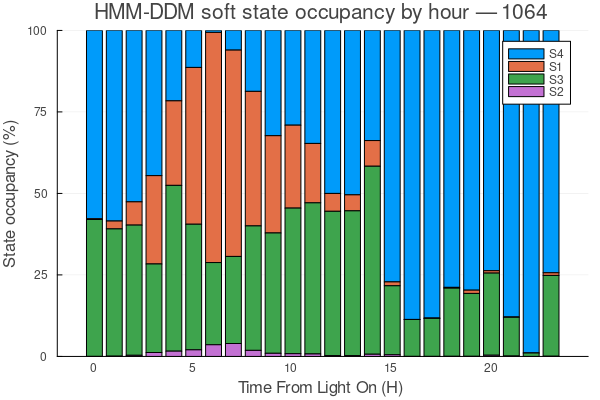

In [67]:
# Get the posterior over states for each trial
γ, _ = forward_backward(hmm, all_results; seq_ends=seq_ends)

# 2) Build the index order used when concatenating trials (to align with trial_datetime)
#    This mirrors how you created `all_results`.
idxs_by_date = Vector{Vector{Int}}()
for date in unique_dates
    day_indices = findall(dates .== date)
    # keep the same order you used above (you can sort within day if needed)
    push!(idxs_by_date, day_indices)
end
concat_idxs = reduce(vcat, idxs_by_date)

# 3) Parse timestamps and extract hour-of-day aligned to γ
#    Robust parser that works whether you have String, Date, or DateTime in the column.
const _dt_formats = (
    dateformat"yyyy-mm-dd HH:MM:SS.s",
    dateformat"yyyy-mm-dd HH:MM:SS",
    dateformat"yyyy-mm-ddTHH:MM:SS.s",
    dateformat"yyyy-mm-ddTHH:MM:SS",
)

parse_dt(x) = x isa DateTime ? x :
              x isa Date     ? DateTime(x) :
              begin
                  s = String(x)
                  for df in _dt_formats
                      try
                          return DateTime(s, df)
                      catch
                      end
                  end
                  error("Couldn't parse trial_datetime string: $x. Add your format to _dt_formats.")
              end

trial_dt_col = rat_of_interest.trial_datetime
hours_concat = [mod(hour(parse_dt(trial_dt_col[i])) - 7.5, 24) for i in concat_idxs]

# 4) Compute occupancy by hour
occ_soft = zeros(24, 4)
n_per_hour = zeros(Int, 24)

for h in 0:23
    idx_h = findall(x -> floor(Int, x) == h, hours_concat)  # Bin fractional hours
    n = length(idx_h)
    n_per_hour[h+1] = n
    if n > 0
        m = dropdims(mean(γ[:, idx_h]; dims=2); dims=2)
        occ_soft[h+1, :] = permutedims(m)
    else
        occ_soft[h+1, :] .= 0.0
    end
end

# Sanity check: each hour's soft occupancy should sum to ~1
println("max deviation from 1: ",
        maximum(abs.(sum(occ_soft, dims=2) .- 1)))

# Prepare % values and mask empty hours (no trials) with NaN so they don't plot
y = occ_soft .* 100
for h in 1:24
    if n_per_hour[h] == 0
        y[h, :] .= NaN  # avoids misleading partial stacks for empty hours
    end
end

state_labels = ["S1", "S2", "S3", "S4"]
hours = 0:23

# Stacked bars: the key is bar_position = :stack
p = plot(fontfamily="helvetica")

order = [4, 1, 3, 2]

groupedbar!(hours, occ_soft[:, order] .* 100, bar_position = :stack,
           xlabel="Time From Light On (H)", ylabel="State occupancy (%)",
           labels=permutedims(state_labels[order]), title="HMM-DDM soft state occupancy by hour — $(1064)", fontfamily="helvetica")
p

In [68]:
y

24×4 Matrix{Float64}:
  0.23245      0.00978035   41.9855   57.7723
  2.41548      0.0816924    39.0317   58.4712
  7.13958      0.347038     39.9276   52.5858
 27.0997       1.20667      27.143    44.5506
 25.9351       1.61193      50.8526   21.6004
 48.0893       2.00705      38.5422   11.3615
 70.6274       3.56046      25.2154    0.596672
 63.2892       3.9614       26.7139    6.03542
 41.2808       1.85272      38.1752   18.6913
 29.8322       0.960367     36.9021   32.3053
  ⋮                                   
  1.17642      0.496426     21.1743   77.1529
  0.0264101    0.00447816   11.3098   88.6593
  0.112101     0.00764512   11.6521   88.2282
  0.248072     0.0259889    20.9108   78.8151
  1.00217      0.0407203    19.2819   79.6752
  0.727071     0.36261      25.2005   73.7098
  0.114188     0.121438     11.8656   87.8988
  0.000971953  0.000395129   1.04025  98.9584
  0.830767     0.0459199    24.788    74.3353

In [69]:
# Trial-aligned vectors (match γ columns)
stim_concat   = rat_of_interest.correct_side_numeric[concat_idxs]  # -1/1
choice_concat = rat_of_interest.choose_right[concat_idxs]          # -1/1
hour_bin      = [floor(Int, h) for h in hours_concat]              # 0..23

# empirical correctness: adjust if your definition differs
is_correct = choice_concat .== stim_concat

emp_acc = fill(NaN, 24)
n_per_hour = zeros(Int, 24)
for h in 0:23
    idx = findall(==(h), hour_bin)
    n_per_hour[h+1] = length(idx)
    if !isempty(idx)
        emp_acc[h+1] = mean(is_correct[idx])
    end
end

function pred_accuracy_by_hour(hmm::PriorHMM, state_occ_hour::AbstractMatrix, trials_per_bin::Int=1000)
    K = length(hmm.dists)
    n_hours = size(state_occ_hour, 1)

    sim_acc_hour = zeros(trials_per_bin, n_hours)
    @threads for i in 1:n_hours
        ddm_cat = Categorical(state_occ_hour[i, :])
        for j in 1:trials_per_bin
            # sample a state based on occupancy
            ddm_result = simulateDDM(hmm.dists[rand(ddm_cat)])
            sim_acc_hour[j, i] = ddm_result.choice == ddm_result.s
        end
    end
    mean_acc_hour = dropdims(mean(sim_acc_hour; dims=1); dims=1)
    return mean_acc_hour, sim_acc_hour
end

mean_acc, sim_acc = pred_accuracy_by_hour(hmm, occ_soft, 10000)
        

([0.7604, 0.7693, 0.7638, 0.7395, 0.7276, 0.7164, 0.692, 0.6971, 0.7183, 0.7372  …  0.7425, 0.7823, 0.7839, 0.7884, 0.7779, 0.7806, 0.7718, 0.7825, 0.7881, 0.7764], [1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0; … ; 0.0 1.0 … 1.0 0.0; 1.0 1.0 … 0.0 1.0])

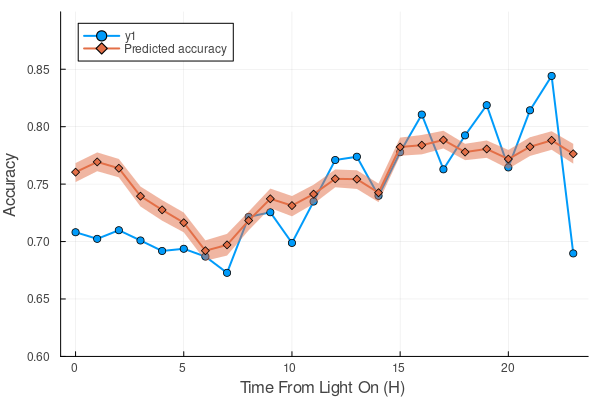

In [73]:
function bootstrap_ci(sim_acc; B::Int=500, α=0.05, rng=Random.default_rng())
    N, H = size(sim_acc)
    boots = Matrix{Float64}(undef, B, H)
    for b in 1:B
        idx = rand(rng, 1:N, N)              # resample trials with replacement
        boots[b, :] = vec(mean(sim_acc[idx, :]; dims=1))
    end
    lower = [quantile(view(boots, :, h), α/2) for h in 1:H]
    upper = [quantile(view(boots, :, h), 1-α/2) for h in 1:H]
    return lower, upper
end

lower, upper = bootstrap_ci(sim_acc; B=500)

p_hat = vec(mean(sim_acc; dims=1))
plot!(0:23, p_hat; ribbon=(p_hat .- lower, upper .- p_hat),
      label="Predicted 95% CI (bootstrap)", lw=2)
acc_24_hr = plot(fontfamily="helvetica", xlabel="Time From Light On (H)", ylabel="Accuracy", ylims=(0.6, 0.9))
plot!(0:23, emp_acc; lw=2, marker=:circle)
plot!(0:23, mean_acc; ribbon=(mean_acc .- lower, upper .- mean_acc), lw=2, marker=:diamond, label="Predicted accuracy")


## RT Hists

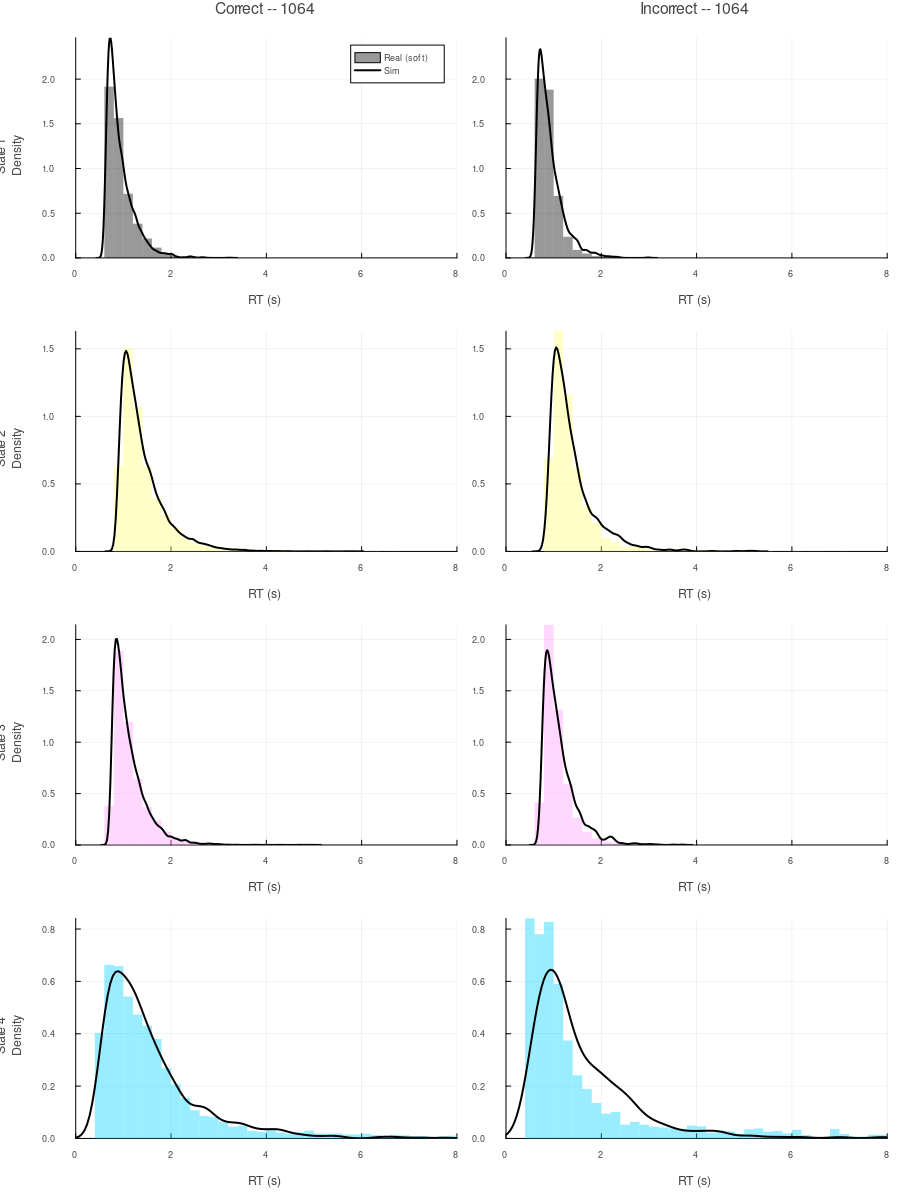

In [10]:
# RT hists
rat_str = String(rat)

K, T = size(γ)
@assert length(all_results) == T "γ and all_results must have same length"

# basic trial info 
rts        = [res.rt for res in all_results]
is_correct = [res.choice == res.s for res in all_results]

# Use *index vectors* instead of Bool masks for indexing
correct_idx   = findall(is_correct)
incorrect_idx = findall(.!is_correct)

# soft RT dists
n_sims = 30000

simulated_rts = Dict{Int, Dict{String, Vector{Float64}}}()

states, data = rand(hmm, n_sims)

for s in 1:K
    simulated_rts[s] = Dict("correct" => Float64[], "incorrect" => Float64[])
    state_s_trials = findall(x -> x == s, states)
    for trial_idx in state_s_trials
        res = data[trial_idx]
        local is_correct = (res.choice == res.s)
        category = is_correct ? "correct" : "incorrect"
        push!(simulated_rts[s][category], res.rt)
    end
end

state_colors = distinguishable_colors(K)

# layout: K rows × 2 columns (Correct / Incorrect)
pA = plot(layout = (K, 2),
          size   = (900, 300*K),
          link   = :x,
          fontfamily = "helvetica")

for s in 1:K
    idx_correct   = 2*(s-1) + 1
    idx_incorrect = 2*(s-1) + 2

    γs = vec(γ[s, :])   # length T

    # Correct
    rts_c = rts[correct_idx]
    w_c   = γs[correct_idx]

    if !isempty(rts_c)
        histogram!(pA[idx_correct],
                   rts_c;
                   weights   = w_c,
                   bins      = 50,
                   normalize = :pdf,
                   fillalpha = 0.4,
                   linealpha = 0.0,
                   color     = state_colors[s],
                   label     = s == 1 ? "Real (soft)" : "")
    end

    sim_rts_c = get(simulated_rts[s], "correct", Float64[])
    if !isempty(sim_rts_c)
        density!(pA[idx_correct],
                 sim_rts_c;
                 linewidth = 2,
                 color     = :black,
                 label     = s == 1 ? "Sim" : "")
    end

    plot!(pA[idx_correct];
          xlabel = "RT (s)",
          ylabel = "State $s\nDensity",
          title  = s == 1 ? "Correct -- $rat_str" : "",
          legend = (s == 1))

    # Incorrect 
    rts_i = rts[incorrect_idx]
    w_i   = γs[incorrect_idx]

    if !isempty(rts_i)
        histogram!(pA[idx_incorrect],
                   rts_i;
                   weights   = w_i,
                   bins      = 50,
                   normalize = :pdf,
                   fillalpha = 0.4,
                   linealpha = 0.0,
                   color     = state_colors[s],
                   label     = "")
    end

    sim_rts_i = get(simulated_rts[s], "incorrect", Float64[])
    if !isempty(sim_rts_i)
        density!(pA[idx_incorrect],
                 sim_rts_i;
                 linewidth = 2,
                 color     = :black,
                 label     = "")
    end

    plot!(pA[idx_incorrect];
          xlabel = "RT (s)",
          ylabel = "",
          title  = s == 1 ? "Incorrect -- $rat_str" : "",
          legend = false)
end

for s in 1:K
    idx_correct   = 2*(s-1) + 1
    idx_incorrect = 2*(s-1) + 2

    # current y-lims for that row's two plots
    y1_min, y1_max = Plots.ylims(pA[idx_correct])
    y2_min, y2_max = Plots.ylims(pA[idx_incorrect])

    # choose a common y-range for the row
    row_min = min(y1_min, y2_min)
    row_max = max(y1_max, y2_max)

    # apply the same y-lims to both panels in that row
    ylims!(pA[idx_correct],   row_min, row_max)
    ylims!(pA[idx_incorrect], row_min, row_max)
end

xlims!(0, 8)

display(pA)

## Param Plots

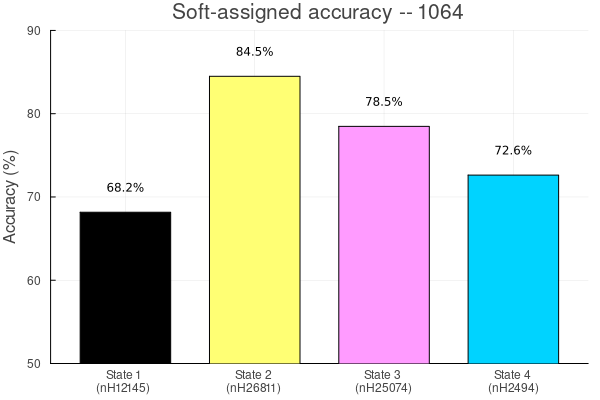

plot_ddm_params (generic function with 1 method)

In [ ]:
accuracies_soft = Float64[]
N_soft          = Float64[]

for s in 1:K
    γs = vec(γ[s, :])

    Ns = sum(γs)                     # expected # trials in state s
    Cs = sum(γs[correct_idx])        # expected # correct

    push!(N_soft, Ns)
    push!(accuracies_soft, Ns > 0 ? 100 * Cs / Ns : NaN)
end

x = 1:K
xtick_labels = ["State $s\n(nH$(round(Int, N_soft[s])))" for s in 1:K]

pB = bar(x, accuracies_soft;
         bar_width = 0.7,
         color     = state_colors,
         ylim      = (0, 100),
         ylabel    = "Accuracy (%)",
         xticks    = (x, xtick_labels),
         legend    = false,
         fontfamily= "helvetica",
         title     = "Soft-assigned accuracy -- $rat_str")

for s in 1:K
    if !isnan(accuracies_soft[s])
        annotate!(pB, (s, accuracies_soft[s] + 3,
                       text(@sprintf("%.1f%%", accuracies_soft[s]),
                            8, :black, :center)))
    end
end

ylims!(50, 90)

display(pB)

# Params plots
function plot_ddm_params(hmm_est;
                         accuracies_soft = nothing,
                         N_soft = nothing,
                         state_colors = nothing,
                         rat_str = "",
                         fontfamily = "helvetica")

    ddms = hmm_est.dists              # Vector{DriftDiffusionModel}
    K    = length(ddms)
    states = 1:K

    # Extract parameters 
    drifts = [d.v for d in ddms]
    bounds = [d.B for d in ddms]
    biases = [d.a₀ for d in ddms]
    t0s    = [d.τ for d in ddms]

    if state_colors === nothing
        state_colors = distinguishable_colors(K)
    end

    xticks_states = (states, ["S$s" for s in states])

    # v
    p_v = bar(states, drifts;
              color = state_colors,
              legend = false,
              xticks = xticks_states,
              ylabel = "Drift v",
              title  = "Drift by state - $rat_str",
              fontfamily = fontfamily)

    # B
    p_a = bar(states, bounds;
              color = state_colors,
              legend = false,
              xticks = xticks_states,
              ylabel = "Boundary a",
              title  = "Boundary by state",
              fontfamily = fontfamily)

    # a0
    p_z = bar(states, biases;
              color = state_colors,
              legend = false,
              xticks = xticks_states,
              ylabel = "Bias z",
              title  = "Starting point bias",
              fontfamily = fontfamily)

    # tau
    p_t = bar(states, t0s;
              color = state_colors,
              legend = false,
              xticks = xticks_states,
              ylabel = "t (s)",
              title  = "Non-decision time",
              fontfamily = fontfamily)

    # Optional annotations: accuracy and N_soft on top of bars
    if accuracies_soft !== nothing || N_soft !== nothing
        for s in states
            label_str = ""

            if N_soft !== nothing
                label_str *= "nH$(round(Int, N_soft[s]))"
            end
            if accuracies_soft !== nothing
                if !isempty(label_str)
                    label_str *= ", "
                end
                label_str *= @sprintf("%.1f%%", accuracies_soft[s])
            end

            if !isempty(label_str)
                y_v = drifts[s]
                y_a = bounds[s]
                y_z = biases[s]
                y_t = t0s[s]

                annotate!(p_v, (s, y_v + 0.05*maximum(abs.(drifts))),
                          text(label_str, 7, :black, :center))
                annotate!(p_a, (s, y_a + 0.05*maximum(abs.(bounds))),
                          text(label_str, 7, :black, :center))
                annotate!(p_z, (s, y_z + 0.05*maximum(abs.(biases))),
                          text(label_str, 7, :black, :center))
                annotate!(p_t, (s, y_t + 0.05*maximum(abs.(t0s))),
                          text(label_str, 7, :black, :center))
            end
        end
    end

    # Combine into 2×2 panel
    p = plot(p_v, p_a, p_z, p_t;
             layout = (2, 2))

    return p
end

## Accuracy Plots

## Accuracy over Time Plots

## ACF PPC Check

In [ ]:
acfs = Vector{Vector{Float64}}(undef, length(results_by_date))
for i in eachindex(results_by_date)
    rts = [x.rt for x in results_by_date[i]]
    acf_vals = autocor(rts, 1:20)
    acfs[i] = acf_vals
end

mean_acfs_real = mean(acfs, dims=1)

nsims = 10000
sim_acfs = Matrix{Float64}(undef, 20, nsims)
@threads for i in 1:nsims
    states, data = rand(hmm, 1000)
    rts = [x.rt for x in data]
    acf = autocor(rts, 1:20)
    sim_acfs[:, i] = acf
end

mean_sim_acfs = mean(sim_acfs, dims=2)

# 94% credible interval across simulations, per lag
ci_low  = [quantile(x, 0.03) for x in eachrow(sim_acfs)]
ci_high = [quantile(x, 0.97) for x in eachrow(sim_acfs)]

lags = 1:20

# plotting
auto_corr_ppc = plot(
    lags, mean_sim_acfs;
    ribbon = (mean_sim_acfs .- ci_low, ci_high .- mean_sim_acfs),
    label = "PPC mean ± 94% CI",
    xlabel = "Lag",
    ylabel = "ACF",
    fontfamily = "helvetica",
)

# overlay empirical mean ACF
plot!(auto_corr_ppc, lags, mean_acfs_real;
      seriestype = :scatter,
      marker = :circle,
      label = "data mean ACF")